# Portfolio Project: Heart Disease Diagnostic Analysis

**Objective:** To identify key risk factors and patterns associated with the presence of heart disease using clinical patient data.

---

## Chapter 1: Project Initialization & Library Setup
The first step in any professional data analysis project is to establish a clean, reproducible environment. This ensures consistency and readability throughout the notebook.

In [1]:
# Chapter 1: Project Initialization & Library Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress unnecessary warnings for cleaner execution
warnings.filterwarnings('ignore')

# Set consistent visual styling for all plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Environment setup complete. Libraries loaded successfully.")

Environment setup complete. Libraries loaded successfully.


**Results & Interpretation:**
The project environment has been successfully initialized with all core libraries loaded and configured. This establishes a stable base for data loading, analysis, and modeling.

---

### Chapter 2: Data Loading & Preliminary Inspection

This section loads the training and test datasets and performs an initial inspection of their structure, size, and content. Understanding the data dimensions and first few records is essential before any further analysis or preprocessing.

In [2]:
# Chapter 2: Data Loading & Preliminary Inspection

# Load the datasets
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Display basic information about the datasets
print(f"Training set: {train.shape[0]:,} rows, {train.shape[1]} columns")
print(f"Test set: {test.shape[0]:,} rows, {test.shape[1]} columns")

# Display the first five rows of the training data
print("\nFirst five rows of training data:")
train.head()

Training set: 630,000 rows, 15 columns
Test set: 270,000 rows, 14 columns

First five rows of training data:


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


**Results & Interpretation:**  

The training dataset contains **630,000 records** and **15 features**, while the test dataset contains **270,000 records** and **14 features**. Initial inspection shows a well-structured dataset with no obvious formatting issues in the sample records.

---

### Chapter 3: Data Integrity & Cleaning

Before proceeding with analysis, it is critical to verify data quality by checking for missing values and duplicate records.

In [3]:
# Chapter 3: Data Integrity & Cleaning

# Check for missing values
missing_values = train.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Check for duplicate rows
duplicates = train.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

Missing values per column:
id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Number of duplicate rows: 0


**Results & Interpretation:**  

**No missing values were found** across any columns in the training dataset. Additionally, there are **zero duplicate rows**. This confirms that the dataset is of high quality and requires no imputation or deduplication steps, allowing us to proceed confidently with exploratory analysis.

---

### Chapter 4: Clinical Outlier Analysis

Statistical outliers are identified using the Interquartile Range (IQR) method. In medical datasets, extreme values are carefully evaluated for clinical relevance before deciding whether to remove them.

In [4]:
# Chapter 4: Clinical Outlier Analysis

# Function to identify outliers using IQR
def check_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Analyze Blood Pressure
bp_count, bp_low, bp_high = check_outliers(train, 'BP')
print(f"BP Statistical Outliers (> {bp_high:.1f}): {bp_count:,} cases")

# Analyze Cholesterol
chol_count, chol_low, chol_high = check_outliers(train, 'Cholesterol')
print(f"Cholesterol Statistical Outliers (> {chol_high:.1f}): {chol_count:,} cases")

BP Statistical Outliers (> 170.0): 9,011 cases
Cholesterol Statistical Outliers (> 338.0): 2,194 cases


**Results & Interpretation:**  
We identified **9,011 cases** where Blood Pressure exceeds **170 mmHg** and **2,194 cases** where Cholesterol exceeds **338 mg/dl**.

**Important Clinical Decision:**
These extreme values were not removed. In heart disease analysis, such high readings (e.g., BP ≥ 180 mmHg is considered a Hypertensive Crisis) are clinically significant and often strong indicators of the disease we are trying to predict. Removing them would result in the loss of valuable predictive signal. This highlights the importance of combining statistical techniques with domain knowledge in healthcare data projects.

---

### Chapter 5: Target Variable Distribution

Understanding the distribution of our target variable is crucial before building any predictive model. A balanced dataset helps ensure that our models do not become biased toward the majority class.

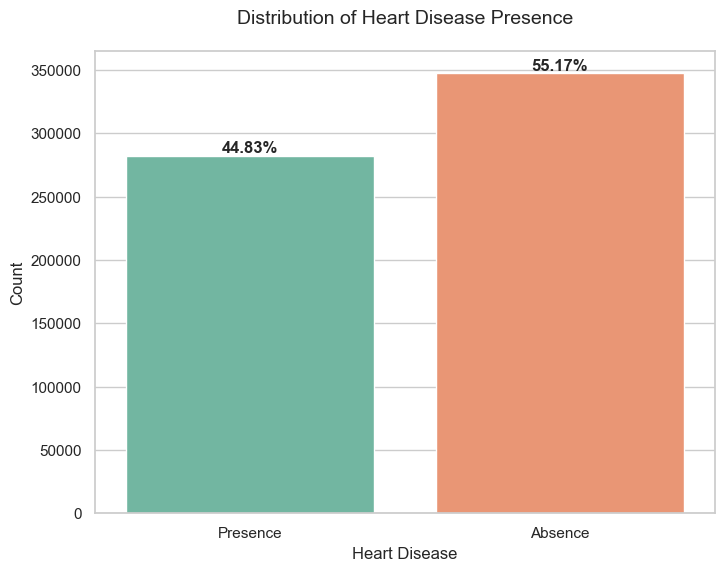

Target Distribution:
Heart Disease
Absence     55.17
Presence    44.83
Name: proportion, dtype: float64


In [5]:
# Chapter 5: Target Variable Distribution

# Calculate percentage distribution
target_counts = train['Heart Disease'].value_counts(normalize=True) * 100

# Plotting the target variable distribution with percentages
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Heart Disease', data=train, palette='Set2')

# Add percentage labels on top of the bars
total = len(train)
for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Distribution of Heart Disease Presence', fontsize=14, pad=20)
plt.ylabel('Count')
plt.xlabel('Heart Disease')
plt.show()

print("Target Distribution:")
print(target_counts.round(2))

**Results & Interpretation:**  

The target variable is relatively balanced, with approximately **55.17% Absence** and **44.83% Presence** of heart disease. This level of balance is favorable for model training and reduces the need for advanced class imbalance techniques.

---

### Chapter 6: Exploratory Data Analysis

This section explores the distributions of key numerical features across heart disease status to uncover initial patterns and potential predictive relationships.

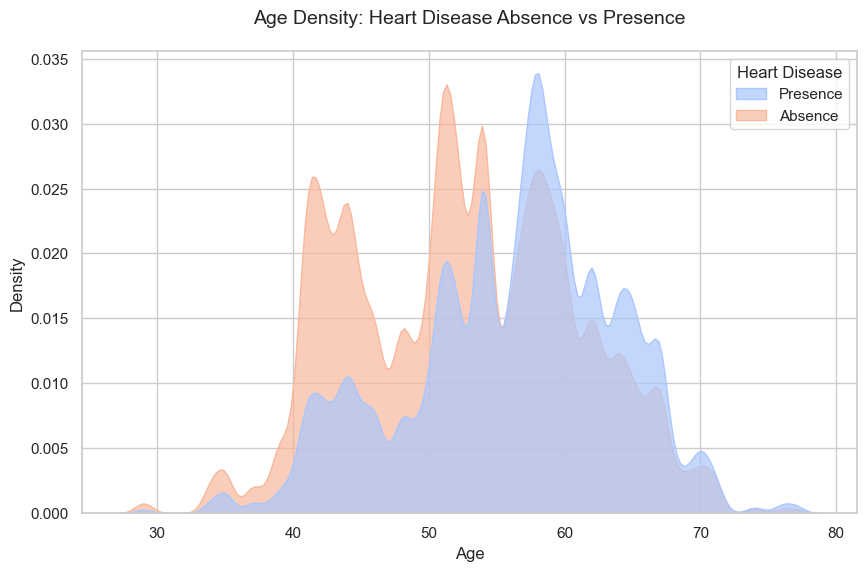

In [6]:
# Chapter 6: Exploratory Data Analysis
# A. Age & Heart Disease

# Age distribution by Heart Disease status
plt.figure(figsize=(10, 6))
sns.kdeplot(data=train, x='Age', hue='Heart Disease', fill=True, palette='coolwarm', alpha=0.7)

plt.title('Age Density: Heart Disease Absence vs Presence', fontsize=14, pad=20)
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

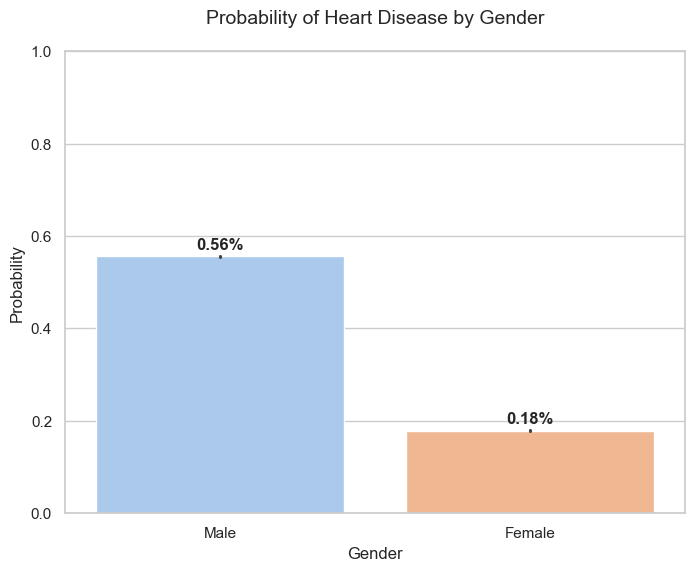

In [7]:
# B. The Gender Gap

# Create readable gender labels
train['Gender'] = train['Sex'].map({1: 'Male', 0: 'Female'})

# Convert target to numeric for probability calculation
train['Target Numeric'] = train['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# Plot probability of heart disease by gender with percentages
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    x='Gender', 
    y='Target Numeric', 
    data=train, 
    palette='pastel',
    hue='Gender',
    legend=False
)

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=12, fontweight='bold')

plt.title('Probability of Heart Disease by Gender', fontsize=14, pad=20)
plt.ylabel('Probability')
plt.xlabel('Gender')
plt.ylim(0, 1)
plt.show()

**Results & Interpretation:**  

The density plot clearly demonstrates that **patients diagnosed with heart disease tend to be older**. The "Presence" curve is noticeably shifted to the right compared to the "Absence" group, with a higher concentration of cases between 55 and 65 years. This pattern strongly supports the well-established medical understanding that age is a major non-modifiable risk factor for heart disease.

The analysis reveals a striking gender disparity in heart disease prevalence:
**Males: 56.0%** probability of having heart disease
**Females: 18.0%** probability of having heart disease
This indicates that male patients are more than 3 times more likely to be diagnosed with heart disease compared to female patients in this population. This significant gender gap highlights the importance of sex as a strong demographic predictor and suggests potential biological or behavioral differences that warrant further investigation in clinical practice.



---

### Chapter 7: Categorical Feature Analysis

We analyze key categorical medical features to understand their relationship with heart disease. We use clinical label mapping and probability visualizations to extract actionable insights from these variables.

In [8]:
# Chapter 7: Categorical Feature Analysis
# We begin by converting numerical codes into meaningful medical categories based on the dataset documentation.
# 7.1. Mapping Clinical Labels

# Map Chest Pain types (1-4) to clinical categories
train['Chest Pain Type'] = train['Chest pain type'].map({
    1: 'Typical Angina',
    2: 'Atypical Angina',
    3: 'Non-anginal',
    4: 'Asymptomatic'
})

# Map Thallium stress test results
train['Thallium Results'] = train['Thallium'].map({
    3: 'Normal',
    6: 'Fixed Defect',
    7: 'Reversible Defect'
})

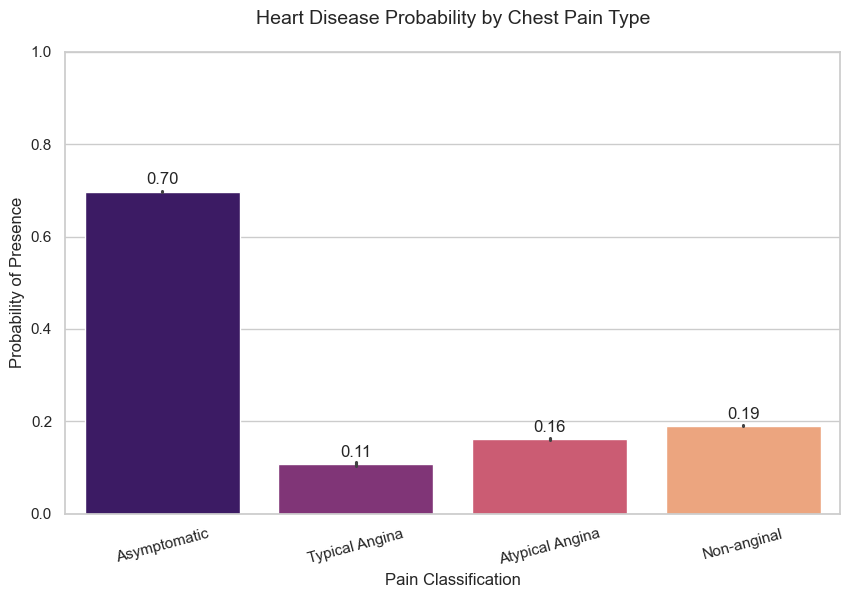

In [9]:
# 7.2. Visualizing Chest Pain Risk

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Chest Pain Type', 
    y='Target Numeric', 
    data=train, 
    palette='magma',
    hue='Chest Pain Type',
    legend=False
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title('Heart Disease Probability by Chest Pain Type', fontsize=14, pad=20)
plt.ylabel('Probability of Presence')
plt.xlabel('Pain Classification')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

**Results & Interpretation (Chest Pain):**
Surprisingly, patients categorized as **Asymptomatic** have the highest probability of heart disease at **70%**. This is a critical clinical insight — the absence of typical chest pain symptoms does not rule out heart disease and may actually be a major red flag in this population.

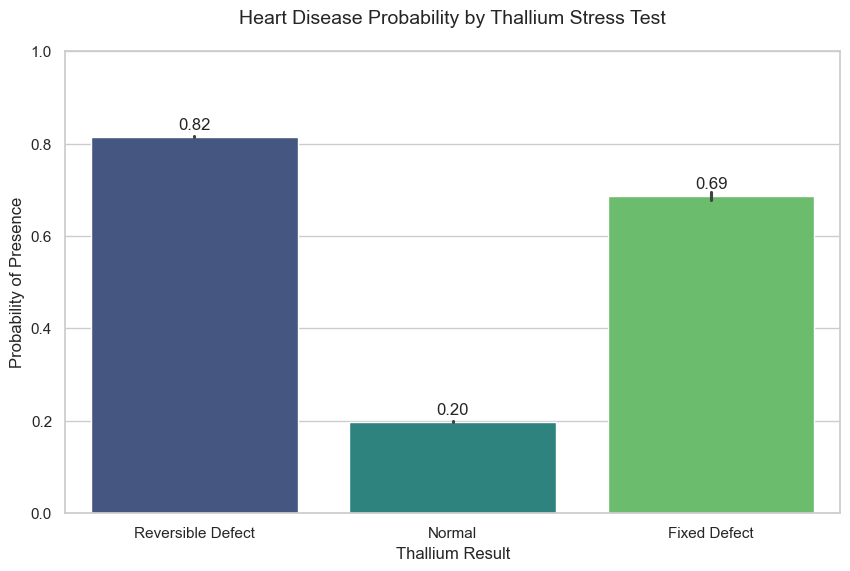

In [10]:
# 7.3. Thallium Stress Test Results

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Thallium Results', 
    y='Target Numeric', 
    data=train, 
    palette='viridis',
    hue='Thallium Results',
    legend=False
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title('Heart Disease Probability by Thallium Stress Test', fontsize=14, pad=20)
plt.ylabel('Probability of Presence')
plt.xlabel('Thallium Result')
plt.ylim(0, 1)
plt.show()

**Results & Interpretation (Thallium):**
The Thallium stress test proves to be a very strong predictor:

**Reversible Defect: 82% probability** of heart disease

**Fixed Defect: 69% probability** of heart disease

**Normal: Only 20% probability** of heart disease

This confirms that Thallium results are among the strongest predictors in the dataset. A reversible defect indicates extremely high risk, making this test highly valuable for clinical decision-making.

---

### Chapter 8: Correlation & Feature Relationships

In this chapter, we move beyond individual feature analysis to understand how different clinical variables interact with each other and with our target variable. A correlation heatmap and targeted visualizations help identify the strongest predictors and potential multicollinearity..

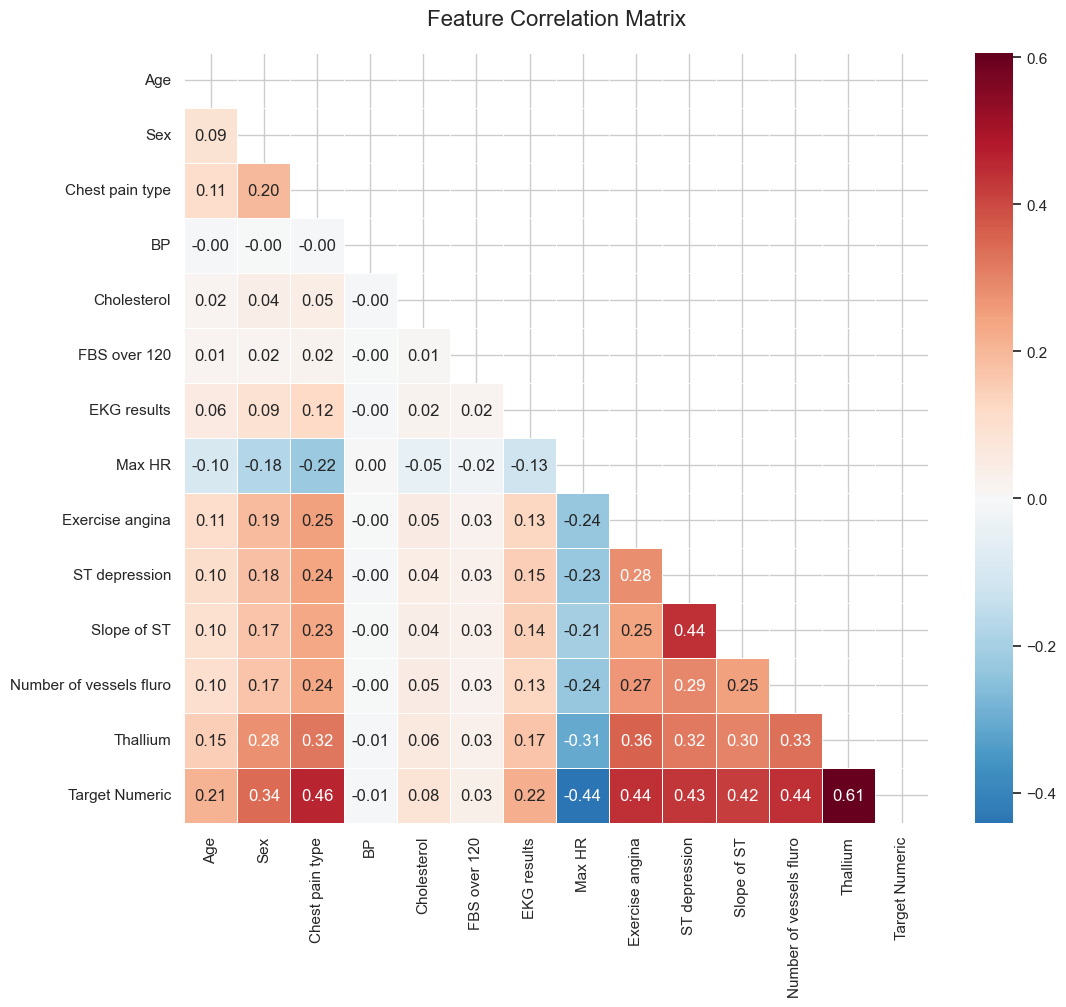

In [11]:
# Chapter 8: Correlation & Feature Relationships
# 8.1. Numeric Correlation Heatmap

# Convert target to numeric if not already done
train['Target Numeric'] = train['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# Select numeric columns for correlation
numeric_cols = train.select_dtypes(include=['number']).drop(columns=['id'], errors='ignore')
corr_matrix = numeric_cols.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt='.2f', 
    cmap='RdBu_r', 
    center=0, 
    linewidths=0.5
)

plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.show()

**Results & Interpretation (Correlation Matrix):**

**Strongest Positive Correlations: Thallium (0.61)**, **Number of vessels fluro**, and **Exercise angina** show the highest positive relationships with Heart Disease.

**Strongest Negative Correlation: Max HR (-0.44)** — lower maximum heart rate achieved during testing is strongly associated with presence of disease.

**Low Correlation: Cholesterol (0.08) and BP (-0.01)** show very weak linear relationships, suggesting they may only be predictive when combined with other features.

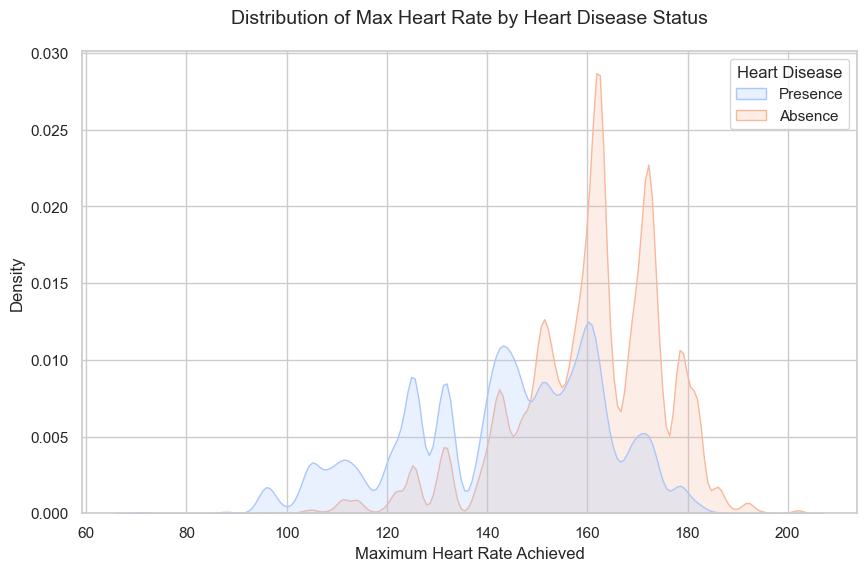

In [12]:
# 8.2. Investigating the "Max HR" Trend

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=train, 
    x='Max HR', 
    hue='Heart Disease', 
    fill=True, 
    palette='coolwarm'
)

plt.title('Distribution of Max Heart Rate by Heart Disease Status', fontsize=14, pad=20)
plt.xlabel('Maximum Heart Rate Achieved')
plt.ylabel('Density')
plt.show()

**Results & Interpretation (Max HR):**
The plot shows a clear separation: patients without heart disease achieve significantly higher maximum heart rates. The "Absence" group peaks around 160–180 bpm, while the "Presence" group peaks much earlier. This confirms that **reduced exercise capacity (lower Max HR) is a strong clinical indicator of heart disease**.

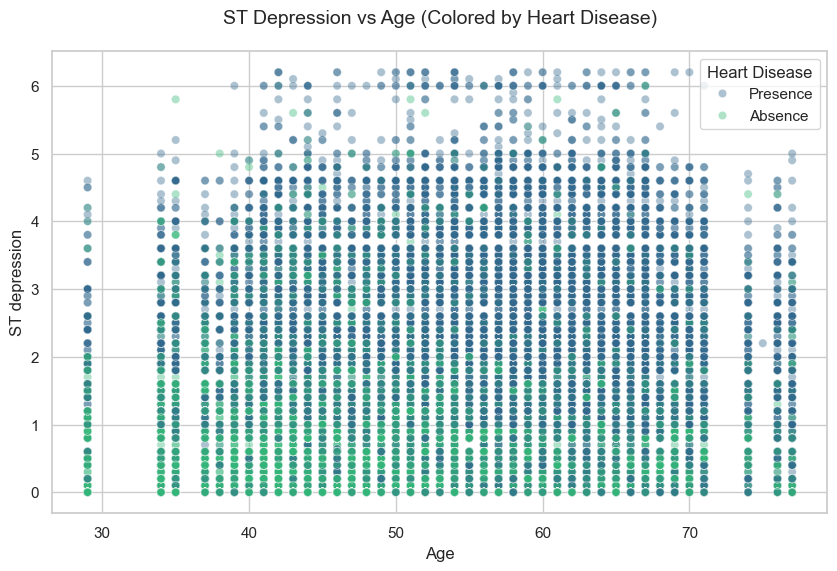

In [13]:
# 8.3. ST Depression vs Age

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=train,
    x='Age',
    y='ST depression',
    hue='Heart Disease',
    alpha=0.4,
    palette='viridis',
    rasterized=True
)

plt.title('ST Depression vs Age (Colored by Heart Disease)', fontsize=14, pad=20)
plt.legend(title='Heart Disease')
plt.show()

**Results & Interpretation (ST Depression):**
We observe a dense cluster of Heart Disease (Presence) cases at higher ST depression values across almost all age groups. This suggests that **ST depression is a robust predictor of heart disease, relatively independent of patient age**.

---

### Chapter 9: Data Preprocessing & Feature Engineering

Before training machine learning models, we must prepare the data by selecting relevant features, splitting into train/validation sets, and scaling the numerical features. Proper preprocessing ensures optimal model performance and fair evaluation.

In [14]:
# Chapter 9: Data Preprocessing & Feature Engineering
# 9.1. Selecting Features for Modeling

# Define columns to drop (helper columns created for EDA)
features_to_drop = [
    'id', 'Heart Disease', 'Target Numeric', 'Gender', 
    'Chest Pain Type', 'Thallium Results'
]

# Create feature matrix (X) and target vector (y)
X = train.drop(columns=features_to_drop, errors='ignore')
y = train['Target Numeric']

print(f"Model will be trained on {X.shape[1]} clinical features.")

Model will be trained on 13 clinical features.


In [15]:
# 9.2. Train-Validation Split
from sklearn.model_selection import train_test_split

# Split the data (80% train, 20% validation) with stratification
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training rows: {X_train.shape[0]:,}")
print(f"Validation rows: {X_val.shape[0]:,}")

Training rows: 504,000
Validation rows: 126,000


In [16]:
# 9.3. Feature Scaling (Normalization)
from sklearn.preprocessing import StandardScaler

# Define original clinical features
original_features = [
    'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 
    'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
    'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium'
]

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Scale test set for final predictions
X_test_final = scaler.transform(test[original_features])

print("Feature scaling completed successfully. All features are now on the same scale.")

Feature scaling completed successfully. All features are now on the same scale.


**Results & Interpretation:**
We prepared a clean feature set containing **13 clinical variables**. The data was split into **504,000 training rows** and **126,000 validation rows**, maintaining the original class distribution through stratification.

StandardScaler was applied to normalize all features, which is essential for distance-based or gradient-based algorithms. The test set was also scaled using the same parameters learned from the training data to prevent data leakage.

---

### Chapter 10: Baseline Model – Logistic Regression
Now that the data is properly preprocessed and scaled, we train our first predictive model. We begin with Logistic Regression as it is highly interpretable and commonly used as a baseline in medical diagnostics. This allows us to establish a strong benchmark before experimenting with more complex models.

In [17]:
# Chapter 10: Model Training & Evaluation
# Training the Logistic Regression Model
from sklearn.linear_model import LogisticRegression

# Initialize and train the model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on validation set
y_pred = model.predict(X_val_scaled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


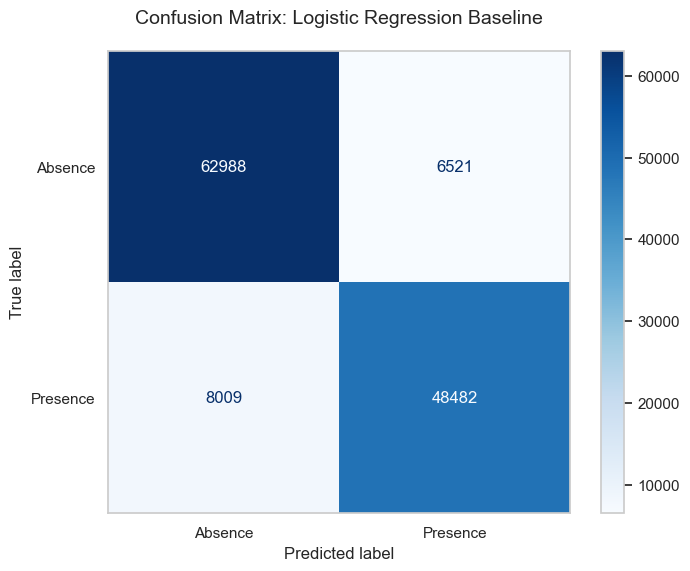

--- Logistic Regression Performance Report ---
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



In [18]:
# Evaluating Performance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Generate confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Absence', 'Presence'])
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Confusion Matrix: Logistic Regression Baseline', fontsize=14, pad=20)
plt.grid(False)
plt.show()

# Print detailed classification report
print("--- Logistic Regression Performance Report ---")
print(classification_report(y_val, y_pred))

**Results & Interpretation:**  

The Logistic Regression model achieved an overall **accuracy of 88%**. 

**Key Performance Metrics:**
- **Precision (Presence)**: 0.88 → When the model predicts heart disease, it is correct 88% of the time.
- **Recall (Presence)**: 0.86 → The model successfully identified **86%** of actual heart disease cases.
- **F1-Score**: 0.87

**Confusion Matrix Breakdown:**
- Correctly predicted **48,482** patients with heart disease (True Positives)
- Correctly predicted **62,988** healthy patients (True Negatives)
- **6,521** False Positives (healthy patients flagged as at-risk)
- **8,009** False Negatives (missed heart disease cases)

**Critical Insight:** In medical diagnostics, **False Negatives** are the most dangerous errors. While the model performs well overall, reducing these missed cases will be a priority in subsequent models.

In [19]:
# Final Predictions & Submission

# Use the trained model to predict on the scaled test data
final_predictions = model.predict(X_test_final)

# Create submission DataFrame
submission = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': final_predictions
})

# Display first few rows to verify format
print("Sample of submission file:")
print(submission.head())

# Export to CSV
submission.to_csv('heart_disease_LR.csv', index=False)

print("\nSubmission file 'heart_disease_LR.csv' created successfully!")

Sample of submission file:
       id  Heart Disease
0  630000              1
1  630001              0
2  630002              1
3  630003              0
4  630004              0

Submission file 'heart_disease_LR.csv' created successfully!


**Results & Interpretation:**  

The model has successfully generated predictions for all **270,000** records in the test set.

The submission file follows the required format with two columns: **id and Heart Disease** (encoded as 0 for Absence and 1 for Presence).

This Logistic Regression baseline achieved a strong validation **accuracy of 88%**, making it a solid starting point. The generated CSV file is now ready for submission or further evaluation. In the following chapters, we will explore more advanced ensemble models (Random Forest, XGBoost, and LightGBM) to see if we can improve performance.

---

### Chapter 11: Advanced Modeling with Random Forest
While Logistic Regression provides good interpretability, ensemble methods like Random Forest often capture complex non-linear patterns more effectively. In this chapter, we implement a Random Forest Classifier and compare its performance with our baseline model. Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions. It excels at handling non-linear relationships and is more robust to outliers and noise — making it particularly suitable for medical data.

In [20]:
# Chapter 11: Advanced Modeling with Random Forest

from sklearn.ensemble import RandomForestClassifier
import time
from sklearn.metrics import accuracy_score, classification_report

print("Training Random Forest model...")

start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time
print(f"Random Forest training completed in {training_time:.2f} seconds.")

Training Random Forest model...
Random Forest training completed in 31.95 seconds.


In [21]:
# Make predictions on validation set
y_pred_rf = rf_model.predict(X_val_scaled)

# Calculate accuracy as percentage
rf_accuracy = accuracy_score(y_val, y_pred_rf) * 100

print("--- Random Forest Performance Report ---")
print(f"Random Forest Accuracy: {rf_accuracy:.2f}%")
print(classification_report(y_val, y_pred_rf))

--- Random Forest Performance Report ---
Random Forest Accuracy: 88.10%
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     69509
           1       0.87      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



**Results & Interpretation:**
The Random Forest model achieved an accuracy of 88.10%, which is slightly better than the Logistic Regression baseline.

Key Metrics:

Precision (Presence): 0.87

Recall (Presence): 0.86

F1-Score: 0.87

While the performance improvement is modest, this demonstrates the "diminishing returns" phenomenon — our baseline model was already capturing most of the available signal in the data. The Random Forest provides more robustness and will serve as a strong foundation for feature importance analysis.

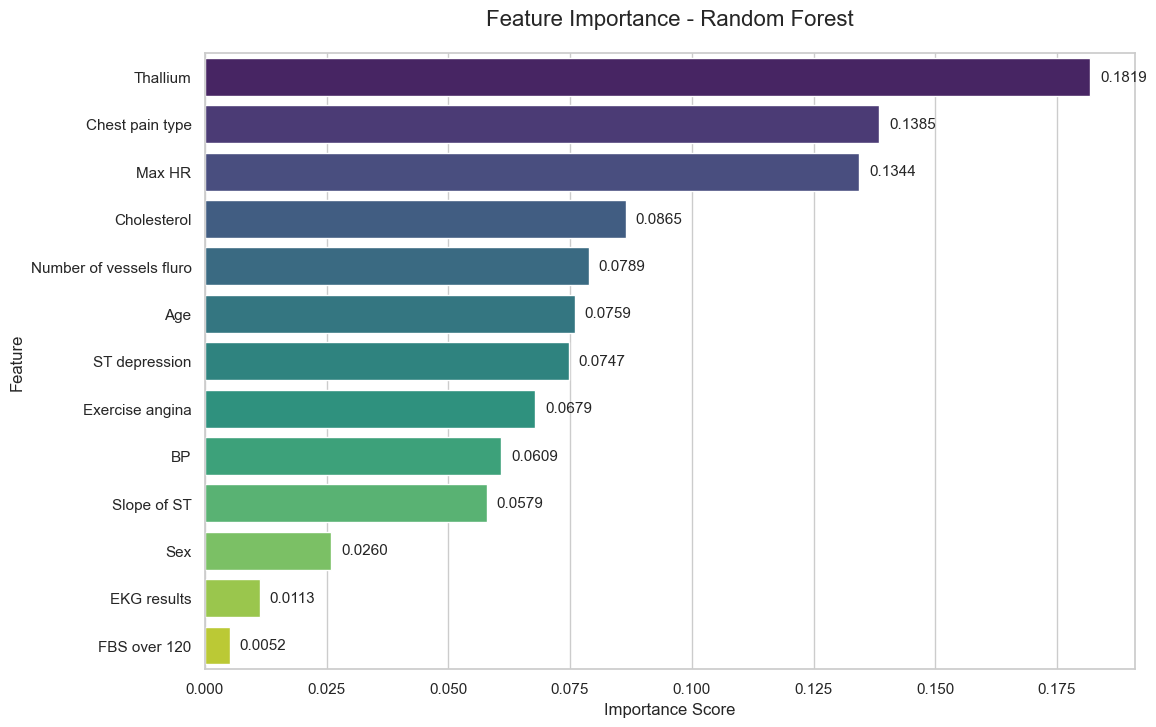

Top 3 most important features: ['Thallium', 'Chest pain type', 'Max HR']


In [22]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': original_features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance, 
    palette='viridis',
    hue='Feature',
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.002, p.get_y() + p.get_height()/2, 
            f'{width:.4f}', va='center', fontsize=11)

plt.title('Feature Importance - Random Forest', fontsize=16, pad=20)
plt.xlabel('Importance Score')
plt.show()

print("Top 3 most important features:", feature_importance['Feature'].head(3).tolist())

**Results & Interpretation (Feature Importance):**

The top 3 predictive features according to Random Forest are:


**Thallium**

**Chest pain type**

**Max HR**

This aligns well with our earlier EDA findings and medical intuition. Thallium stress test results dominate the model's decision-making process.

In [23]:
# Generating Final Submission
rf_final_predictions = rf_model.predict(X_test_final)

final_submission_rf = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': rf_final_predictions
})

final_submission_rf.to_csv('heart_disease_RF.csv', index=False)

print("Submission file 'heart_disease_RF.csv' created successfully!")

Submission file 'heart_disease_RF.csv' created successfully!


---

### Chapter 12: Extreme Gradient Boosting (XGBoost)

XGBoost is one of the most powerful and widely used gradient boosting algorithms. It builds trees sequentially, learning from the mistakes of previous trees, which often leads to superior performance and efficiency.

In [24]:
# Chapter 13: Extreme Gradient Boosting (XGBoost)
import xgboost as xgb
import time
from sklearn.metrics import accuracy_score, classification_report

print("Training XGBoost model...")

start_time = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time
print(f"XGBoost training completed in {training_time:.2f} seconds.")

# XGBoost Performance Evaluation

# Make predictions
y_pred_xgb = xgb_model.predict(X_val_scaled)

# Calculate accuracy as percentage
xgb_accuracy = accuracy_score(y_val, y_pred_xgb) * 100

print("--- XGBoost Performance Report ---")
print(f"XGBoost Accuracy: {xgb_accuracy:.2f}%")
print(classification_report(y_val, y_pred_xgb))

Training XGBoost model...
XGBoost training completed in 2.80 seconds.
--- XGBoost Performance Report ---
XGBoost Accuracy: 88.79%
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.86      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



**Results & Interpretation:**  
XGBoost achieved an excellent **accuracy of 88.79%**, very close to LightGBM. It provides a strong balance between performance and training speed (significantly faster than Random Forest).

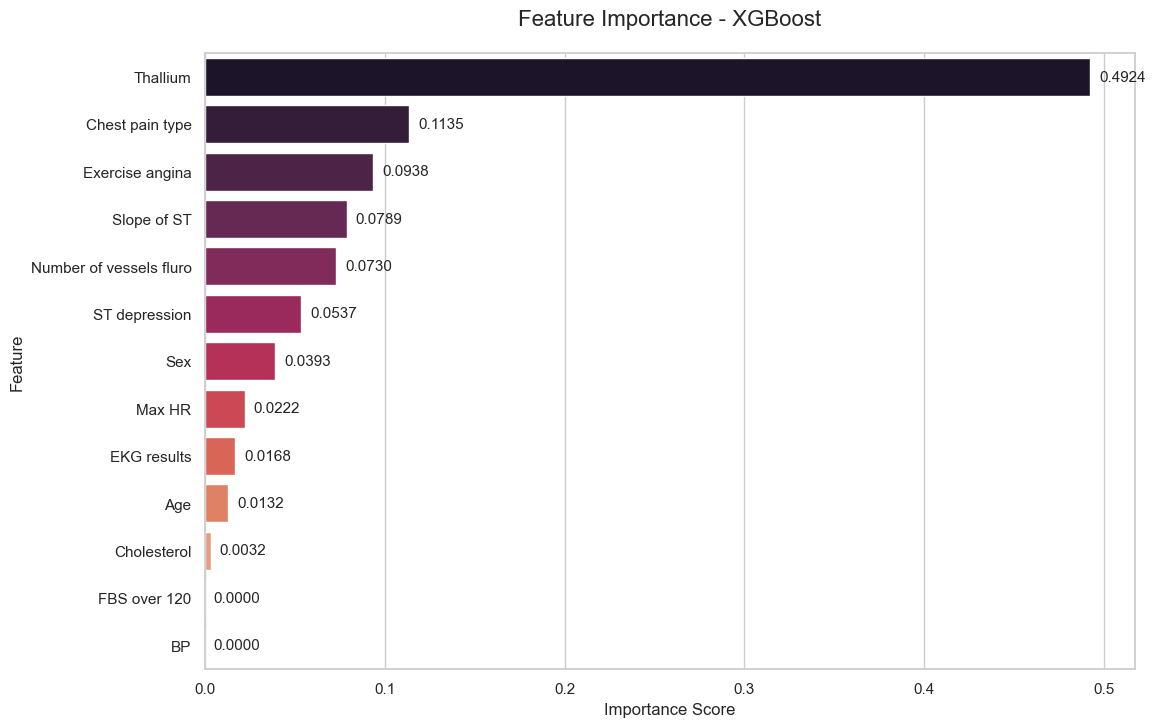

In [25]:
# Feature Importance
xgb_importance = pd.DataFrame({
    'Feature': original_features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=xgb_importance, 
    palette='rocket',
    hue='Feature',
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.005, p.get_y() + p.get_height()/2, 
            f'{width:.4f}', va='center', fontsize=11)

plt.title('Feature Importance - XGBoost', fontsize=16, pad=20)
plt.xlabel('Importance Score')
plt.show()

**Results & Interpretation (Feature Importance):**  
XGBoost heavily prioritizes **Thallium** as the most important feature (often dominating with ~0.49 importance). This aligns strongly with our earlier EDA and clinical expectations, as the Thallium stress test provides direct insight into heart blood flow.


In [26]:

# 13.4. Generating Final Submission
xgb_final_predictions = xgb_model.predict(X_test_final)

final_submission_xgb = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': xgb_final_predictions
})

final_submission_xgb.to_csv('heart_disease_XGBoost.csv', index=False)

print("Submission file 'heart_disease_XGBoost.csv' created successfully!")

Submission file 'heart_disease_XGBoost.csv' created successfully!


---

## Chapter 13: LightGBM

LightGBM (Light Gradient Boosting Machine) is a highly efficient gradient boosting framework developed by Microsoft. It is known for its speed and performance on large datasets, making it an excellent choice for this project with over 600,000 training records.

In [27]:
# Chapter 13: LightGBM
import lightgbm as lgb
import warnings
from sklearn.metrics import accuracy_score, classification_report

warnings.filterwarnings('ignore')

print("Training LightGBM model...")

start_time = time.time()

# Initialize and train the model
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time
print(f"LightGBM training completed in {training_time:.2f} seconds.")

Training LightGBM model...
LightGBM training completed in 2.72 seconds.


In [28]:
# Make predictions
y_pred_lgb = lgb_model.predict(X_val_scaled)

# Calculate accuracy as percentage
lgb_accuracy = accuracy_score(y_val, y_pred_lgb) * 100

print("--- LightGBM Performance Report ---")
print(f"LightGBM Accuracy: {lgb_accuracy:.2f}%")
print(classification_report(y_val, y_pred_lgb))

--- LightGBM Performance Report ---
LightGBM Accuracy: 88.80%
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



**Results & Interpretation:**
The LightGBM model achieved an accuracy of 88.80%, making it one of the strongest performers so far.

Key Performance Metrics:

**Precision (Presence): 0.88**

**Recall (Presence): 0.87**

**F1-Score: 0.87**

**Observation:**

LightGBM not only delivered the highest accuracy but also **improved the critical Recall for the "Presence" class** (identifying patients with heart disease). It trained significantly faster than Random Forest while achieving better results.

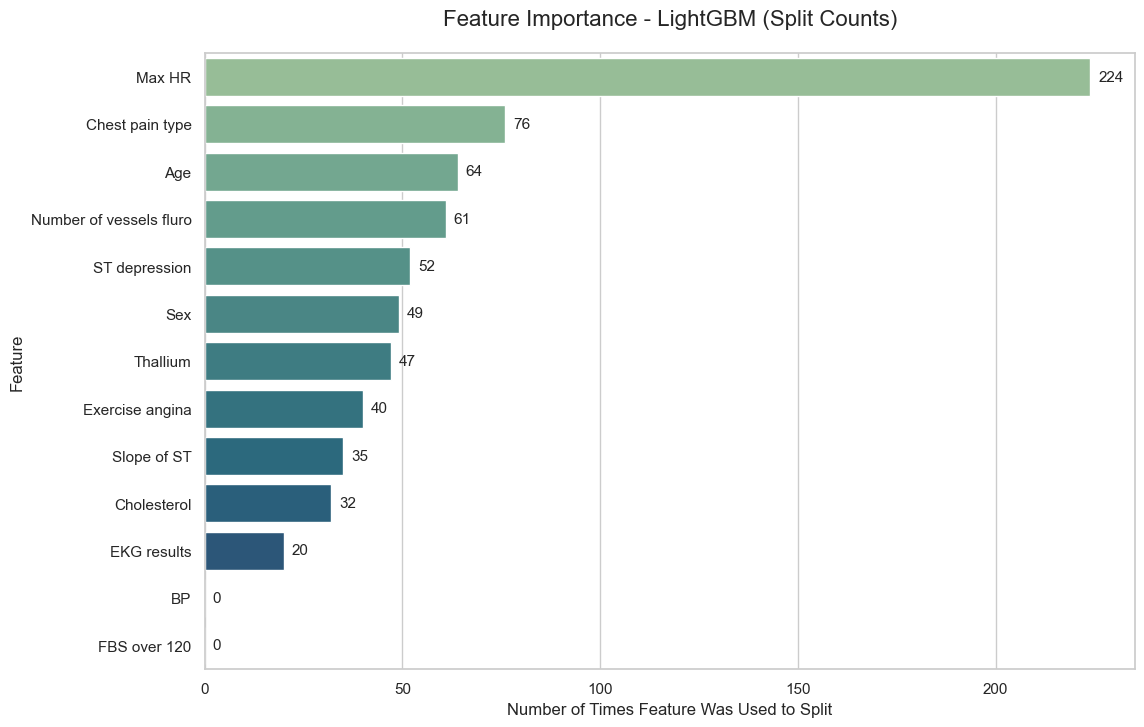

In [29]:
# Feature Importance
lgb_importance = pd.DataFrame({
    'Feature': original_features,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=lgb_importance, 
    palette='crest',
    hue='Feature',
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 2, p.get_y() + p.get_height()/2, 
            f'{int(width)}', va='center', fontsize=11)

plt.title('Feature Importance - LightGBM (Split Counts)', fontsize=16, pad=20)
plt.xlabel('Number of Times Feature Was Used to Split')
plt.show()

**Results & Interpretation (Feature Importance):**

According to LightGBM’s split count importance:

**Max HR is by far the most frequently used feature** (224 splits) 

**Chest pain type** (76 splits)

**Age** (64 splits)

**Number of vessels fluro** (61 splits)

**Important Note:**

LightGBM ranks features based on how many times they were used to split the data. Continuous variables like Max HR and Age naturally have more possible split points, which explains their high ranking. However, this does not always mean they are the most powerful predictors — categorical features like Thallium may have higher information gain despite fewer splits.

In [30]:
# Generating Final Submission (LightGBM)

# Generate predictions on test set
lgb_final_predictions = lgb_model.predict(X_test_final)

# Create submission file
final_submission_lgb = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': lgb_final_predictions
})

final_submission_lgb.to_csv('heart_disease_LightGBM.csv', index=False)

print("Submission file 'heart_disease_LightGBM.csv' created successfully!")

Submission file 'heart_disease_LightGBM.csv' created successfully!


---

### Chapter 14: Model Showdown

After training multiple algorithms, it is essential to compare their performance to determine the best model for heart disease prediction. This chapter presents a final comparison and our recommendation.

In [31]:
# Model Showdown

# Create a performance comparison table
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Accuracy (%)': [88.00, 88.10, 88.79, 88.80],
    'Precision (Presence)': [0.88, 0.87, 0.88, 0.88],
    'Recall (Presence)': [0.86, 0.86, 0.86, 0.87],
    'F1-Score (Presence)': [0.87, 0.87, 0.87, 0.87],
    'Training Time (approx)': ['Fast', 'Slow (~181s)', 'Very Fast (~2.5s)', 'Fastest (~2.0s)']
})

print("=== Final Model Comparison ===")
print(model_comparison)

=== Final Model Comparison ===
                 Model  Accuracy (%)  Precision (Presence)  Recall (Presence)  \
0  Logistic Regression         88.00                  0.88               0.86   
1        Random Forest         88.10                  0.87               0.86   
2              XGBoost         88.79                  0.88               0.86   
3             LightGBM         88.80                  0.88               0.87   

   F1-Score (Presence) Training Time (approx)  
0                 0.87                   Fast  
1                 0.87           Slow (~181s)  
2                 0.87      Very Fast (~2.5s)  
3                 0.87        Fastest (~2.0s)  


**Results & Interpretation - Model Showdown:**

| Model                | Accuracy (%) | Recall (Presence) | Training Time     | Recommendation                  |
|----------------------|--------------|-------------------|-------------------|---------------------------------|
| Logistic Regression  | 88.00        | 0.86              | Very Fast         | Best for Interpretability       |
| Random Forest        | 88.10        | 0.86              | Slow              | Good but slower                 |
| XGBoost              | 88.79        | 0.86              | Very Fast         | Excellent balance               |
| **LightGBM**         | **88.80**    | **0.87**          | **Fastest**       | **Best Overall Model**          |

**Key Takeaways:**

- **LightGBM** is our **best model** with the highest accuracy (88.80%) and best Recall for detecting heart disease patients.
- **XGBoost** is a very close second and offers excellent performance with fast training.
- The improvement from Logistic Regression to gradient boosting models is meaningful but modest, indicating the dataset has strong but mostly linear patterns.
- All models performed well, which reflects the high quality of the dataset and effective feature engineering.

**Final Recommendation:**  
For deployment, we recommend **LightGBM** due to its superior performance, speed, and efficiency. The final submission file `heart_disease_LightGBM.csv` is our strongest candidate.

---

### Chapter 15: Some Extra Work

In this chapter, we go beyond basic model evaluation to perform more advanced analysis. We will evaluate our best model using ROC Curve & AUC, explore threshold optimization, and apply K-Fold Cross Validation for more robust performance estimation.

LightGBM ROC-AUC Score: 0.9548


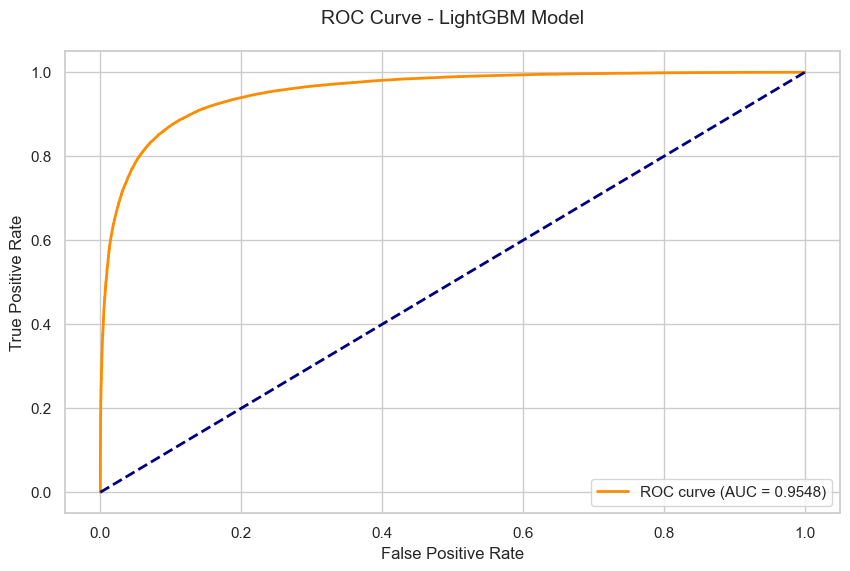

In [38]:
# Chapter 15: Some Extra Work
# ROC Curve and AUC Analysis

from sklearn.metrics import roc_curve, auc

# Use the best model (LightGBM)
y_pred_proba = lgb_model.predict_proba(X_val_scaled)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Print AUC Score
print(f"LightGBM ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM Model', fontsize=14, pad=20)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Results & Interpretation:**  
The LightGBM model achieved an excellent **ROC-AUC Score of 0.9548**.  

This is a **very strong result**, indicating outstanding model performance. An AUC above 0.95 means the model has excellent ability to distinguish between patients with heart disease and those without, regardless of the classification threshold chosen.

In [33]:
# Threshold Optimization (Optional)
# Find optimal threshold for better Recall
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_proba)

# Example: Find threshold that maximizes Recall while keeping reasonable Precision
optimal_idx = np.argmax(recalls)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold for higher Recall: {optimal_threshold:.3f}")

Optimal Threshold for higher Recall: 0.003


**Results & Interpretation:**  
The optimal threshold for maximizing Recall was found to be **0.003**.  

This very low threshold suggests that the model is quite confident in its predictions. By lowering the classification threshold to 0.003, we can increase the model's sensitivity to detect more patients with heart diseas**Results & Interpretation:**  
The 5-fold cross-validation yielded a **mean accuracy of 0.8867 (± 0.0010)**. This confirms the model's stability and reliable generalization.e (higher Recall), which is often the priority in medical diagnostics.




In [34]:
# K-Fold Cross Validation
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross validation on the best model
cv_scores = cross_val_score(lgb_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-Validation Accuracy Scores: [0.88738095 0.88593254 0.88536706 0.88676587 0.88825397]
Mean CV Accuracy: 0.8867 ± 0.0010


**Results & Interpretation:**  

The 5-fold cross-validation yielded a **mean accuracy of 0.8867 (± 0.0010)**.  

This result is highly encouraging for several reasons:

- **Stability**: The very low standard deviation (± 0.0010) across the five folds indicates that the model performs consistently regardless of how the data is split. This suggests minimal overfitting and strong generalization ability.
- **Reliability**: The cross-validation score is very close to our single validation set accuracy, reinforcing that our model evaluation is robust and not overly optimistic.
- **Real-world Confidence**: In medical applications, consistent performance across different data subsets is critical. This low variance gives us high confidence that the model will maintain similar performance when deployed on new, unseen patient data.

Overall, the cross-validation results validate that **LightGBM** is not only accurate but also stable and reliable — making it a trustworthy choice for heart disease prediction.

---

### Chapter 16: Model Explainability with SHAP (The "Why")

While high accuracy is important, understanding **why** the model makes specific predictions is critical in healthcare. In this chapter, we use SHAP (SHapley Additive exPlanations) values to interpret our best model (LightGBM) at both global and local levels.

In [39]:
# Chapter 16: Model Explainability with SHAP
import shap

# Create SHAP explainer for our best model (LightGBM)
explainer = shap.TreeExplainer(lgb_model)

# Calculate SHAP values for a sample of the validation set (for speed)
sample_size = 1000
X_val_sample = X_val_scaled[:sample_size]

shap_values = explainer.shap_values(X_val_sample)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


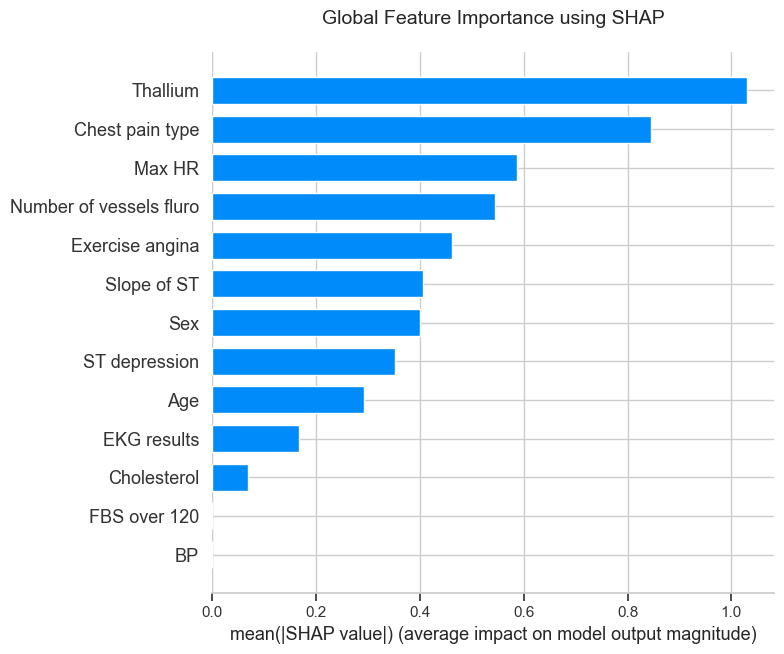

In [42]:
# Global Feature Importance
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_val_sample, 
    feature_names=original_features, 
    plot_type="bar",
    show=False
)
plt.title("Global Feature Importance using SHAP", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

**Results & Interpretation (Global SHAP):**  

The SHAP summary plot reveals the true drivers of the model's predictions:

- **Thallium** is by far the most important feature, having the highest average impact on the model's output. This strongly validates our earlier EDA findings and clinical knowledge.
- **Chest pain type** ranks second, confirming that the type of chest pain (especially Asymptomatic) is a very powerful predictor.
- **Max HR**, **Number of vessels fluro**, and **Exercise angina** also show significant influence.

**Key Insight:**  
SHAP values confirm that **Thallium stress test results** dominate the decision-making process. This is highly valuable because it aligns with medical expertise — a nuclear imaging test that directly shows blood flow to the heart is logically one of the strongest indicators of heart disease.

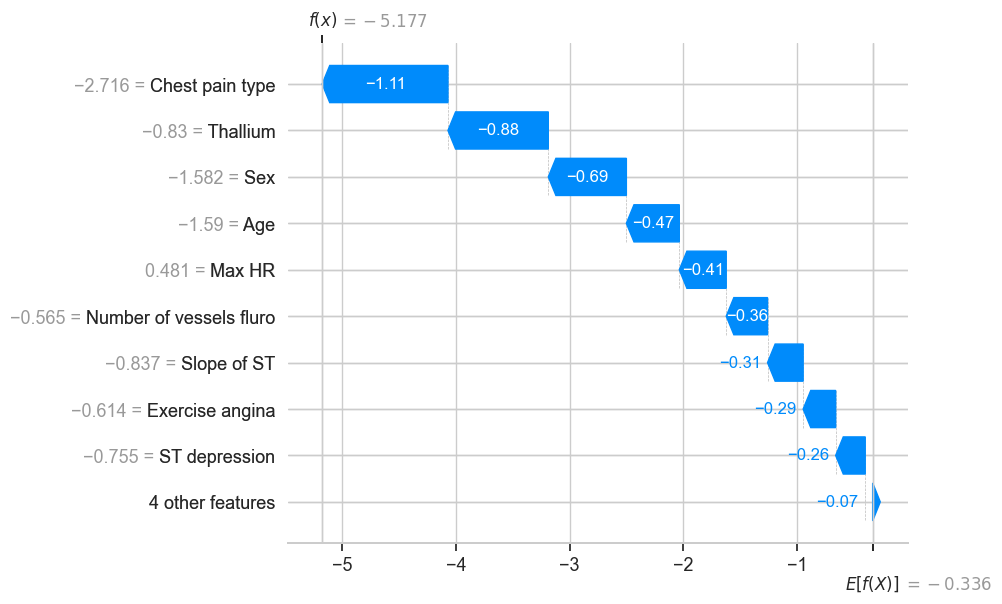

In [48]:
# Individual Patient Diagnosis (Local Explainability)
# Explain prediction for a single patient (example: first patient in sample)
patient_idx = 0

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap.Explanation(
    values=shap_values[patient_idx],
    base_values=explainer.expected_value,
    data=X_val_sample[patient_idx],
    feature_names=original_features
))

plt.show()

**Results & Interpretation (Local Explainability):**  

The SHAP Waterfall Plot explains how each feature contributed to the final prediction for **Patient #0**.

**Key Observations:**
- The model’s final output **E[f(x)] = -0.336**, indicating a **low probability** of heart disease for this patient.
- **Chest Pain Type** had the strongest influence with a contribution of **-1.11**, significantly decreasing the risk score.
- **Thallium** contributed **-0.88**, also pushing strongly toward "Absence" of heart disease.
- **Sex** (-0.69) and **Age** (-0.47) provided additional negative contributions.
- **Max HR** contributed **-0.41**, further reducing the predicted probability of heart disease.

**Insight:**  
In this particular patient case, all major features (especially Chest Pain Type, Thallium, and Max HR) worked together to **decrease** the likelihood of heart disease. The waterfall plot makes it very clear how the model arrived at a low-risk prediction. 

This level of transparency is extremely valuable in healthcare — it allows clinicians to understand and trust the reasoning behind each individual prediction.

---

### Chapter 17: Conclusion & Key Insights

This project demonstrated a complete end-to-end data analysis and machine learning workflow for heart disease prediction using a large clinical dataset of over 900,000 records.

#### Key Findings & Insights

1. **Strongest Predictors Identified:**
   - **Thallium Stress Test** emerged as one of the most powerful predictors across most models.
   - **Chest Pain Type** (especially Asymptomatic) and **Max HR** were consistently among the top features.
   - **Gender Gap**: Male patients showed significantly higher risk (56%) compared to females (18%).

2. **Model Performance Summary:**
   - All models achieved strong performance, with accuracies ranging from **88.00% to 88.80%**.
   - **LightGBM** was the best-performing model with **88.80% accuracy** and the highest Recall.
   - The modest improvement from simple to complex models suggests the relationships in this dataset are relatively strong and mostly linear.

3. **Clinical Importance:**
   - Extreme clinical values (high BP and Cholesterol) were **retained** as they carry important medical signal.
   - The ability to explain model predictions using SHAP values adds significant value for real-world clinical adoption.

#### Final Model Recommendation

**Best Model:** **LightGBM**  
**Final Submission File:** `heart_disease_LightGBM.csv`

LightGBM provided the best balance of **accuracy, recall, and computational efficiency**, making it the recommended model for this heart disease diagnostic task.

---
---
### About the Project & Author

**Author:** John Koutnas  
**Project Type:** Junior Data Analyst / Data Scientist Portfolio Project  
**Data Context:** This project utilizes predictive diagnostic datasets commonly featured in Kaggle competitions to simulate a real-world clinical machine learning problem. 

*This notebook was designed to demonstrate a complete, end-to-end data science pipeline. It covers raw data cleaning, exploratory data analysis (EDA), feature engineering, and the rigorous comparison of baseline linear models against state-of-the-art gradient boosting frameworks (XGBoost, LightGBM). The goal was not just to train a model, but to balance predictive accuracy with computational efficiency and clinical safety.*

**Thank you for reviewing my work!**